# Module 1

## Install & Import Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline

## Load Dataset

In [10]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("papluca/language-identification")

df_train = dataset["train"].to_pandas()
df_valid = dataset["validation"].to_pandas()
df_test  = dataset["test"].to_pandas()

print("Train shape: ",df_train.shape)
print("Test shape: ",df_test.shape)
print("Validation shape: ",df_valid.shape)
print(f"Columns: {list(df_train.columns)}")

Train shape:  (70000, 2)
Test shape:  (10000, 2)
Validation shape:  (10000, 2)
Columns: ['labels', 'text']


## DSA

In [11]:
languages = sorted(df_train["labels"].unique())
print(f"Number of languages: {len(languages)}")
print(f"Languages: {languages}")

Number of languages: 20
Languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


Arabic, Bulgarian, German, Greek, English, Spanish, French, Hindi, Italian, Japanese, Dutch, Polish, Portuguese, Russian, Swahili, Thai, Turkish, Urdu, Vietnamese, Chinese

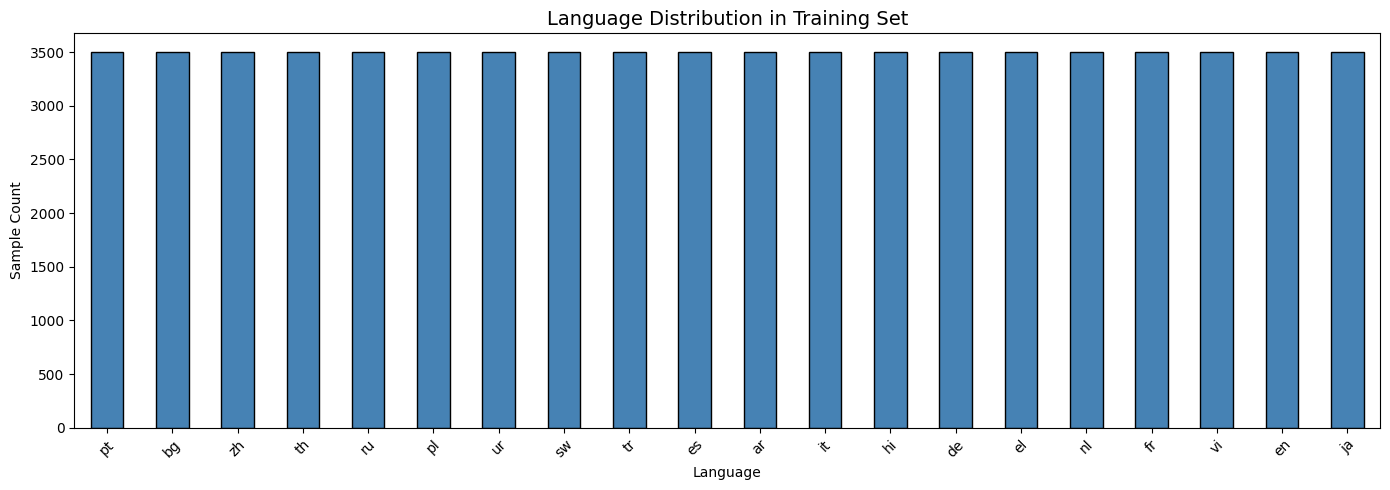

In [13]:
class_counts = df_train["labels"].value_counts()

plt.figure(figsize=(14, 5))
class_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Language Distribution in Training Set", fontsize=14)
plt.xlabel("Language")
plt.ylabel("Sample Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From this plot we can know that the all classes have the same samples and this mean that the dataset is `Balanced`

In [16]:
print("One text per language:\n")
for lang in languages[:]:
    sample = df_train[df_train["labels"] == lang]["text"].iloc[0]
    print(f"[{lang}]: {sample[:100]}")
    print()

One text per language:

[ar]: نعم , هذا صحيح نعم اعتقد ان هناك خطوات كبيرة يتم صنعها في الوقت الحاضر في رعاية المسنين الذين تعرفهم

[bg]: размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до

[de]: Alles in allem ein super schönes Teil, deshalb die 2 Sterne! Denn: Voice Control?! Nein, ein absolut

[el]: Παρά τον εαυτό μου , η γνώμη μου για τη σύνεση του ήταν απείρως αυξημένη .

[en]: Didnt really seem to work much.

[es]: Un producto de una calidad y capacidad increíbles que será el placer de todo amante de la tecnología

[fr]: Le produit m'avait été recommandé par mon pharmacien pour ralentir le développement de mon arthrose.

[hi]: सर ् वसम ् मत शासन ने यह निर ् णय लिया कि राज ् य को एक ही लिंग से अधिक लाभ और protections के लिए एक

[it]: Una donna sta affettando della carne.

[ja]: とてもスタイリッシュで良いと思います。機能性も◎ですね！煩わしくないので皆さんもお使いになられては。

[nl]: Iemand houdt een egel vast.

[pl]: S Jak sobie życzysz: Widzisz, jak Hitler zabija Żydów?

[pt]: o

## Preprocessing

We will not remove non-ASCII to do not destroy language like Arabic or Chinese or any languge 

In [17]:
def preprocess_text(text):
    
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = text.lower()
    return text

In [18]:
df_train["text_clean"] = df_train["text"].apply(preprocess_text)
df_valid["text_clean"] = df_valid["text"].apply(preprocess_text)
df_test["text_clean"] = df_test["text"].apply(preprocess_text)

# Check for nulls
print(f"Null values in train: {df_train['text_clean'].isna().sum()}")
print(f"Empty strings in train: {(df_train['text_clean'] == '').sum()}")
print("\nExample before:", df_train["text"].iloc[0])
print("Example after: ", df_train["text_clean"].iloc[0])

Null values in train: 0
Empty strings in train: 0

Example before: os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.
Example after:  os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.


## Feature Extraction — TF-IDF Vectorizer

I will use **character-level n-grams** (`analyzer='char_wb'`) which works better than word-level for language detection because:
- It captures character patterns unique to each language (e.g., Arabic script, Thai script)
- It handles unknown words and morphological variations gracefully
- It's robust to short texts

In [19]:
X_train = df_train["text_clean"]
y_train = df_train["labels"]

X_val   = df_valid["text_clean"]
y_val   = df_valid["labels"]

X_test  = df_test["text_clean"]
y_test  = df_test["labels"]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (70000,)
X_val shape:   (10000,)
X_test shape:  (10000,)


In [20]:
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=50000,
    sublinear_tf=True,
    strip_accents=None,
    min_df=2
)

In [21]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

TF-IDF matrix shape (train): (70000, 50000)
Vocabulary size: 50,000


## Logestic Regression

In [24]:
print('Start of the training..')


model = LogisticRegression(
    max_iter=1000,
    C=5.0,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_tfidf, y_train)
print("Done...")

Start of the training..


c:\Users\youss\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done...


## Evaluation

In [ ]:
# Evaluate on validation set
y_val_pred = model.predict(X_val_tfidf)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

Validation Accuracy: 0.9951 (99.51%)


In [26]:
# Evaluate on test set
y_test_pred = model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "="*60)
print("Classification Report (Test Set):")
print("="*60)
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9956 (99.56%)

Classification Report (Test Set):
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      1.00      1.00       500
          pt       1.00      1.00      1.00       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr   

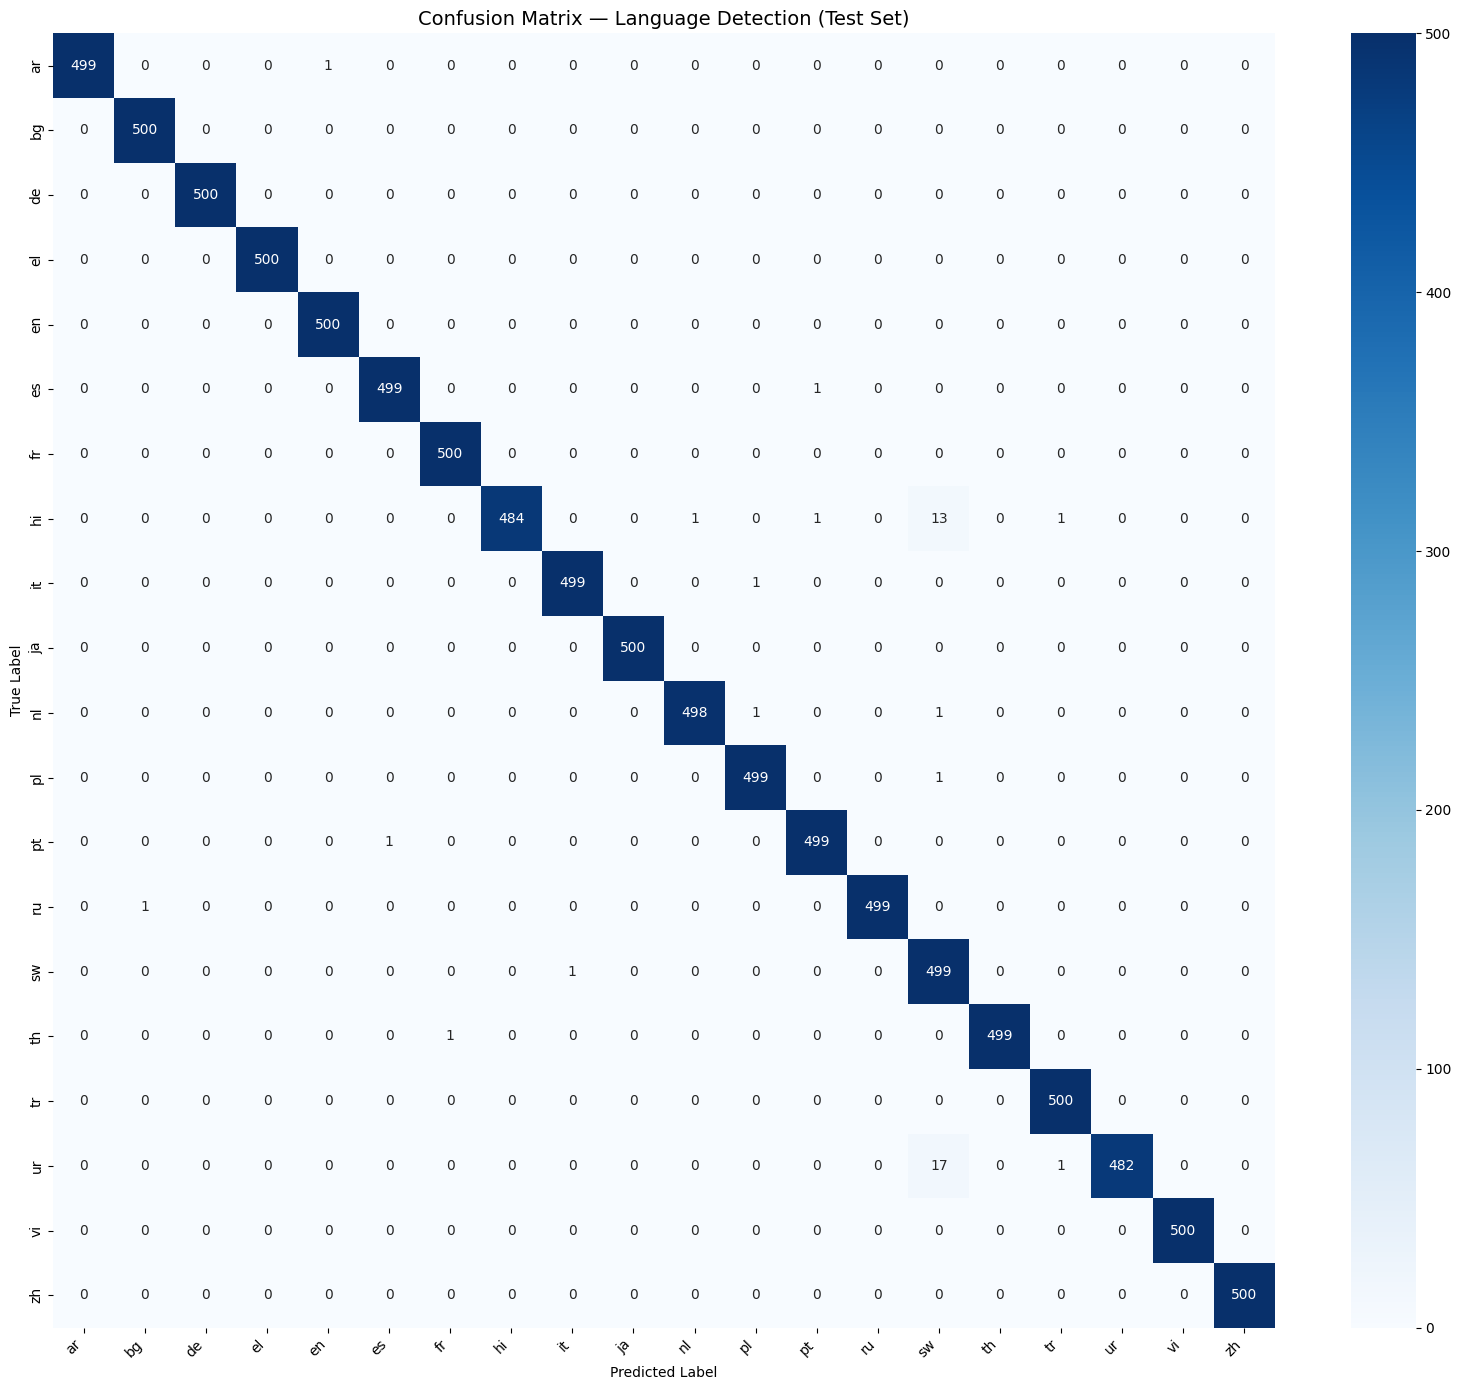

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=languages)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=languages,
    yticklabels=languages
)
plt.title("Confusion Matrix — Language Detection (Test Set)", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

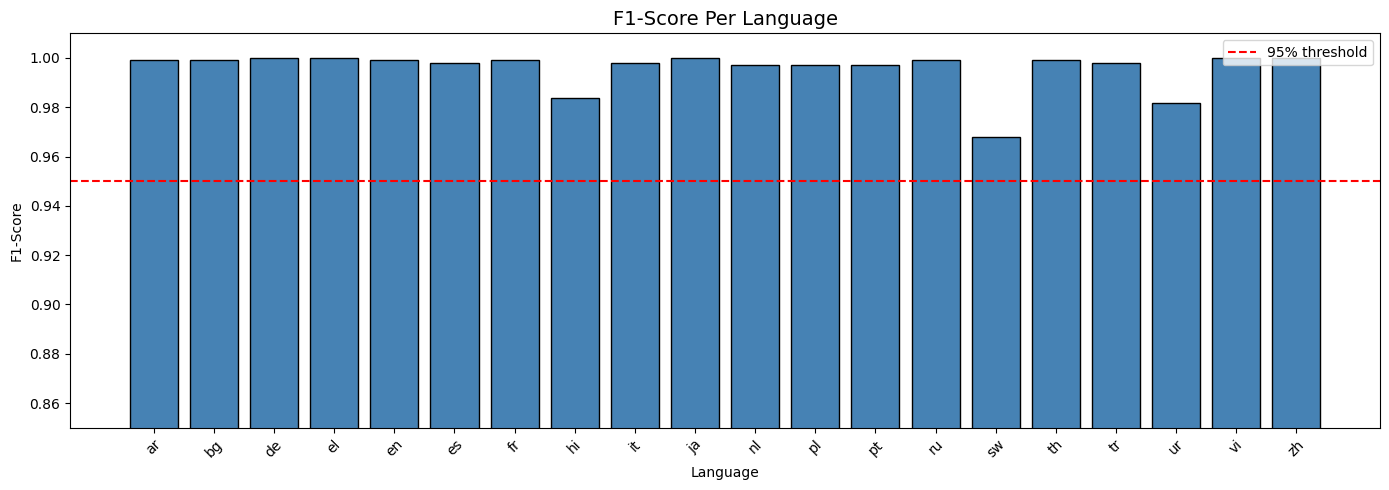

In [28]:
# Per-language accuracy
from sklearn.metrics import classification_report
report = classification_report(y_test, y_test_pred, output_dict=True)
per_lang_f1 = {lang: report[lang]['f1-score'] for lang in languages if lang in report}

plt.figure(figsize=(14, 5))
bars = plt.bar(per_lang_f1.keys(), per_lang_f1.values(), color='steelblue', edgecolor='black')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.title("F1-Score Per Language", fontsize=14)
plt.xlabel("Language")
plt.ylabel("F1-Score")
plt.ylim([0.85, 1.01])
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Saving the Model

In [29]:
# Save both the vectorizer and the classifier
os.makedirs("models", exist_ok=True)

joblib.dump(tfidf,  "models/tfidf_vectorizer.pkl")
joblib.dump(model,  "models/language_classifier.pkl")

print("Models saved")
print("  → models/tfidf_vectorizer.pkl")
print("  → models/language_classifier.pkl")

Models saved
  → models/tfidf_vectorizer.pkl
  → models/language_classifier.pkl


## Inference Simulation

The `hasattr()` function in Python is a built-in utility that checks if an object has a specified attribute. It returns True if the attribute exists, and False otherwise.

In [30]:
def detect_language(text: str) -> str:
    """
    Detects the language of the input text.
    
    Args:
        text (str): Input text from the user.
    
    Returns:
        str: Detected language code (e.g., 'ar', 'en', 'fr').
    """
    if not hasattr(detect_language, "_vectorizer"):
        detect_language._vectorizer = joblib.load("models/tfidf_vectorizer.pkl")
        detect_language._model = joblib.load("models/language_classifier.pkl")

    cleaned = text.strip().lower()

    features = detect_language._vectorizer.transform([cleaned])
    language = detect_language._model.predict(features)[0]

    return language


# ---- Test the inference function ----
test_cases = [
    ("Hello, how are you feeling today?", "en"),
    ("مرحبا، كيف حالك اليوم؟", "ar"),
    ("Bonjour, comment vous sentez-vous?", "fr"),
    ("Hallo, wie geht es Ihnen heute?", "de"),
    ("こんにちは、今日の気分はいかがですか？", "ja"),
]

print("Inference test results:")
print("-" * 55)
all_correct = True
for text, expected in test_cases:
    predicted = detect_language(text)
    status = "Right" if predicted == expected else "Wrong"
    print(f"{status} Expected: {expected} | Predicted: {predicted} | Text: {text[:40]}")
    if predicted != expected:
        all_correct = False

print("-" * 55)
print(f"All correct: {all_correct}")

Inference test results:
-------------------------------------------------------
Right Expected: en | Predicted: en | Text: Hello, how are you feeling today?
Right Expected: ar | Predicted: ar | Text: مرحبا، كيف حالك اليوم؟
Right Expected: fr | Predicted: fr | Text: Bonjour, comment vous sentez-vous?
Right Expected: de | Predicted: de | Text: Hallo, wie geht es Ihnen heute?
Right Expected: ja | Predicted: ja | Text: こんにちは、今日の気分はいかがですか？
-------------------------------------------------------
All correct: True
